REGRESSION TRACK

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, PolynomialFeatures
from sklearn.model_selection import (
    train_test_split, GridSearchCV, KFold, cross_val_score, learning_curve,
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import sklearn

# ---------------------------------------------------------------- global config
RANDOM_STATE = 42
TEST_SIZE    = 0.20
N_FOLDS      = 5


DATA_PATH = "data/data.csv"
TARGET = "strength"
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 1030 rows x 14 columns


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength,water_cement_ratio,total_binder,aggregate_to_cement,cement_water_interaction,age_strength_proxy
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89,1.440188,353.3,12.174719,28754.55,5.291503
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51,0.937235,335.4,11.113019,26736.87,3.741657
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22,0.749597,345.7,7.272371,46850.00,5.291503
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85,0.857140,380.0,6.022534,60648.00,5.291503
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29,1.248700,338.2,11.266723,29922.84,5.291503


In [2]:
import pandas as pd
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cement                    1030 non-null   float64
 1   slag                      1030 non-null   float64
 2   ash                       1030 non-null   float64
 3   water                     1030 non-null   float64
 4   superplastic              1030 non-null   float64
 5   coarseagg                 1030 non-null   float64
 6   fineagg                   1030 non-null   float64
 7   age                       1030 non-null   int64  
 8   strength                  1030 non-null   float64
 9   water_cement_ratio        1030 non-null   float64
 10  total_binder              1030 non-null   float64
 11  aggregate_to_cement       1030 non-null   float64
 12  cement_water_interaction  1030 non-null   float64
 13  age_strength_proxy        1030 non-null   float64
dtypes: float64(13), int

In [3]:
import pandas as pd

missing = pd.DataFrame({"n_missing": df.isna().sum(),"pct_missing": (df.isna().mean()*100).round(2),})
print("Missing values per column:")
print(missing.to_string())
n_dup = df.duplicated().sum()
pct_dup = (n_dup / len(df)) * 100
print(f"\nFully duplicated rows: {n_dup}  ({pct_dup:.2f}% of the data)")

Missing values per column:
                          n_missing  pct_missing
cement                            0          0.0
slag                              0          0.0
ash                               0          0.0
water                             0          0.0
superplastic                      0          0.0
coarseagg                         0          0.0
fineagg                           0          0.0
age                               0          0.0
strength                          0          0.0
water_cement_ratio                0          0.0
total_binder                      0          0.0
aggregate_to_cement               0          0.0
cement_water_interaction          0          0.0
age_strength_proxy                0          0.0

Fully duplicated rows: 25  (2.43% of the data)


In [4]:
import pandas as pd
desc = df.describe().T
desc["skew"] = df.skew()
desc["kurtosis"] = df.kurtosis()
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
cement,1030.0,281.168,104.506,102.000,192.375,272.900,350.000,540.000,0.509,-0.521
slag,1030.0,73.896,86.279,0.000,0.000,22.000,142.950,359.400,0.801,-0.508
ash,1030.0,54.188,63.997,0.000,0.000,0.000,118.300,200.100,0.537,-1.329
water,1030.0,181.567,21.354,121.800,164.900,185.000,192.000,247.000,0.075,0.122
superplastic,1030.0,6.205,5.974,0.000,0.000,6.400,10.200,32.200,0.907,1.411
coarseagg,1030.0,972.919,77.754,801.000,932.000,968.000,1029.400,1145.000,-0.040,-0.599
fineagg,1030.0,773.580,80.176,594.000,730.950,779.500,824.000,992.600,-0.253,-0.102
age,1030.0,45.662,63.170,1.000,7.000,28.000,56.000,365.000,3.269,12.169
strength,1030.0,35.818,16.706,2.330,23.710,34.445,46.135,82.600,0.417,-0.314
water_cement_ratio,1030.0,0.748,0.314,0.267,0.533,0.675,0.935,1.882,0.958,0.734


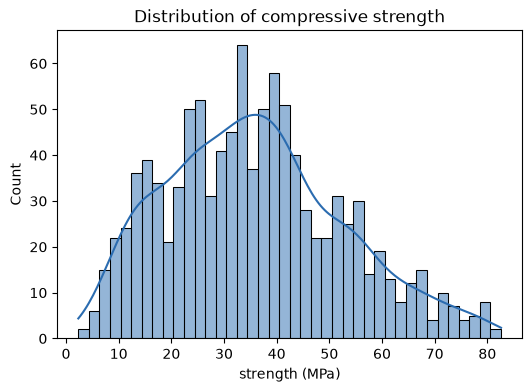

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.histplot(df[TARGET], bins=40, kde=True, color="#2b6cb0")
plt.title("Distribution of compressive strength")
plt.xlabel("strength (MPa)")
plt.ylabel("Count")
plt.show()

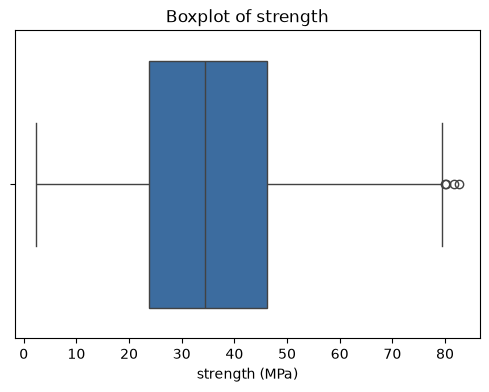

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.boxplot(x=df[TARGET], color="#2b6cb0")
plt.title("Boxplot of strength")
plt.xlabel("strength (MPa)")
plt.show()

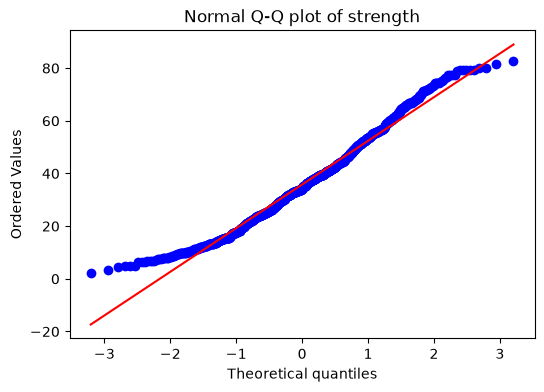

In [7]:
import matplotlib.pyplot as plt
from scipy import stats
plt.figure(figsize=(6, 4))
ax = plt.gca()
stats.probplot(df[TARGET], dist="norm", plot=ax)
plt.title("Normal Q-Q plot of strength")
plt.show()

In [8]:
print(f"mean   : {df[TARGET].mean():.2f} MPa")
print(f"median : {df[TARGET].median():.2f} MPa")
print(f"std    : {df[TARGET].std():.2f} MPa")
print(f"min    : {df[TARGET].min():.2f} MPa")
print(f"max    : {df[TARGET].max():.2f} MPa")
print(f"skew   : {df[TARGET].skew():.3f}")

mean   : 35.82 MPa
median : 34.45 MPa
std    : 16.71 MPa
min    : 2.33 MPa
max    : 82.60 MPa
skew   : 0.417


---
# 3. Preprocessing and the train / test split


In [9]:
# De-duplication
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Before de-duplication: {df.shape[0]} rows")
print(f"After  de-duplication: {df_clean.shape[0]} rows   (removed {df.shape[0] - df_clean.shape[0]})")

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]
print(f"\nX shape: {X.shape}   y shape: {y.shape}")
print("Predictors:", list(X.columns))

Before de-duplication: 1030 rows
After  de-duplication: 1005 rows   (removed 25)

X shape: (1005, 13)   y shape: (1005,)
Predictors: ['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg', 'age', 'water_cement_ratio', 'total_binder', 'aggregate_to_cement', 'cement_water_interaction', 'age_strength_proxy']


## Train / test split

Stratify on binned `strength` (5 quantile bins) so the small held-out set still covers the full strength range.

In [10]:
strength_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=strength_bins,
)

print(f"Training set : {X_train.shape[0]} rows  ({(1-TEST_SIZE)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]} rows  ({TEST_SIZE*100:.0f}%)")

print("\nTarget distribution check (the split must not shift the target):")
print(pd.DataFrame({
    "train": y_train.describe(),
    "test":  y_test.describe(),
}).round(3).to_string())

Training set : 804 rows  (80%)
Test set     : 201 rows  (20%)

Target distribution check (the split must not shift the target):
         train     test
count  804.000  201.000
mean    35.264   35.194
std     16.323   16.171
min      2.330    3.320
25%     23.520   23.350
50%     33.745   34.670
75%     45.080   44.520
max     82.600   79.300


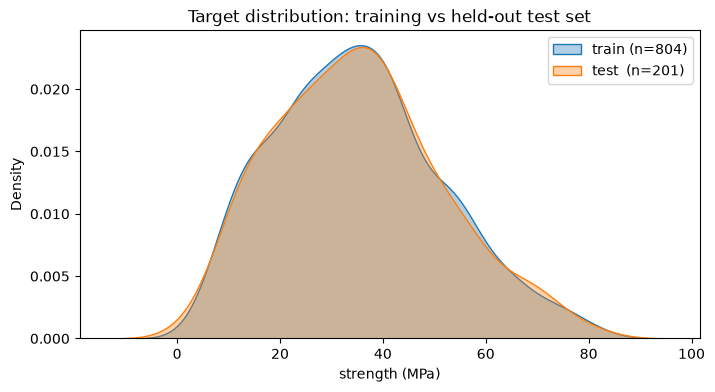

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(y_train, label=f"train (n={len(y_train)})", fill=True, alpha=.35, ax=ax)
sns.kdeplot(y_test,  label=f"test  (n={len(y_test)})",  fill=True, alpha=.35, ax=ax)
ax.set_title("Target distribution: training vs held-out test set")
ax.set_xlabel("strength (MPa)")
ax.legend()
plt.show()

## Shared preprocessing pipeline

`age` gets median-imputed then log1p'd (it's heavily right-skewed); everything else is just median-imputed. Both branches are scaled afterwards. Wrapping this in a `Pipeline` means `GridSearchCV` refits it from scratch on each CV fold, so no fold ever leaks its statistics into another.

In [12]:
LOG_COLS   = ["age"]
OTHER_COLS = [c for c in X.columns if c not in LOG_COLS]

log_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("log1p",  FunctionTransformer(np.log1p, feature_names_out="one-to-one", validate=True)),
])

column_transformer = ColumnTransformer(
    transformers=[
        ("log_age", log_pipe,                             LOG_COLS),
        ("passthru", SimpleImputer(strategy="median"),    OTHER_COLS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# THE shared preprocessor. Cloned into every model pipeline.
preprocessor = Pipeline([
    ("columns", column_transformer),
    ("scale",   StandardScaler()),
])

preprocessor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columns', ...), ('scale', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_age', ...), ('passthru', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_

In [13]:
def make_pipe(model):
    """Wrap any estimator in the shared preprocessing recipe (fresh clone each time)."""
    return Pipeline([("prep", clone(preprocessor)), ("model", model)])


# Materialise the preprocessed matrices once, just for inspection below.
# Models themselves always re-fit the preprocessor inside their own pipeline/CV folds.
_prep_fitted   = clone(preprocessor).fit(X_train)
FEATURE_NAMES  = list(_prep_fitted.get_feature_names_out())
X_train_prep   = pd.DataFrame(_prep_fitted.transform(X_train), columns=FEATURE_NAMES)
X_test_prep    = pd.DataFrame(_prep_fitted.transform(X_test),  columns=FEATURE_NAMES)

print("Feature names after preprocessing (note: 'age' now holds log1p(age)):")
for i, f in enumerate(FEATURE_NAMES, 1):
    print(f"  {i:2d}. {f}")

print(f"\nX_train_prep: {X_train_prep.shape}   X_test_prep: {X_test_prep.shape}")
print("\nSanity check — training features are standardised (mean 0, std 1):")
print(pd.DataFrame({"mean": X_train_prep.mean(), "std": X_train_prep.std(ddof=0)}).round(4).to_string())

Feature names after preprocessing (note: 'age' now holds log1p(age)):
   1. age
   2. cement
   3. slag
   4. ash
   5. water
   6. superplastic
   7. coarseagg
   8. fineagg
   9. water_cement_ratio
  10. total_binder
  11. aggregate_to_cement
  12. cement_water_interaction
  13. age_strength_proxy

X_train_prep: (804, 13)   X_test_prep: (201, 13)

Sanity check — training features are standardised (mean 0, std 1):
                          mean  std
age                        0.0  1.0
cement                    -0.0  1.0
slag                      -0.0  1.0
ash                        0.0  1.0
water                     -0.0  1.0
superplastic              -0.0  1.0
coarseagg                 -0.0  1.0
fineagg                   -0.0  1.0
water_cement_ratio         0.0  1.0
total_binder               0.0  1.0
aggregate_to_cement        0.0  1.0
cement_water_interaction   0.0  1.0
age_strength_proxy         0.0  1.0
